In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
from sklearn.impute import SimpleImputer,KNNImputer

%matplotlib inline

In [2]:
df = pd.read_csv('German_bank.csv')

<Axes: xlabel='checking_balance', ylabel='count'>

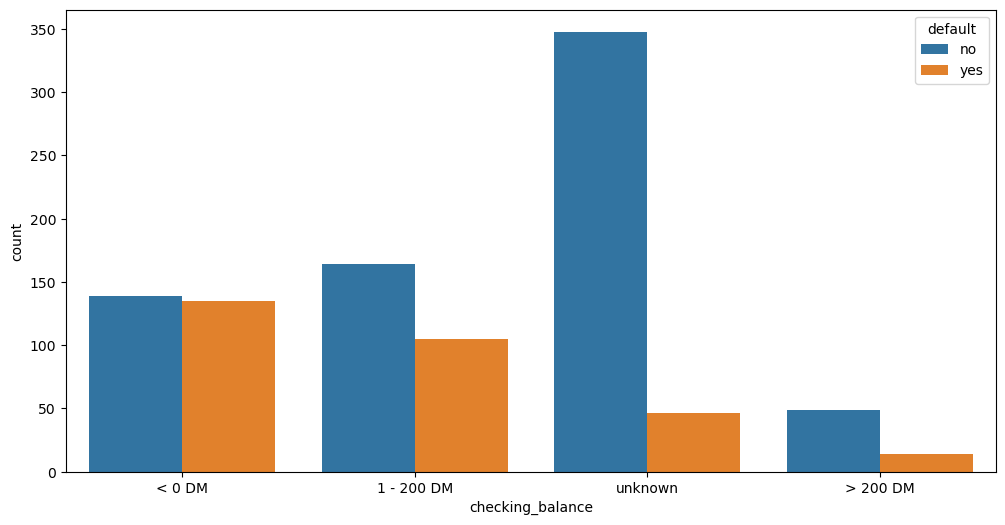

In [3]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="checking_balance",hue="default")

<Axes: xlabel='months_loan_duration', ylabel='count'>

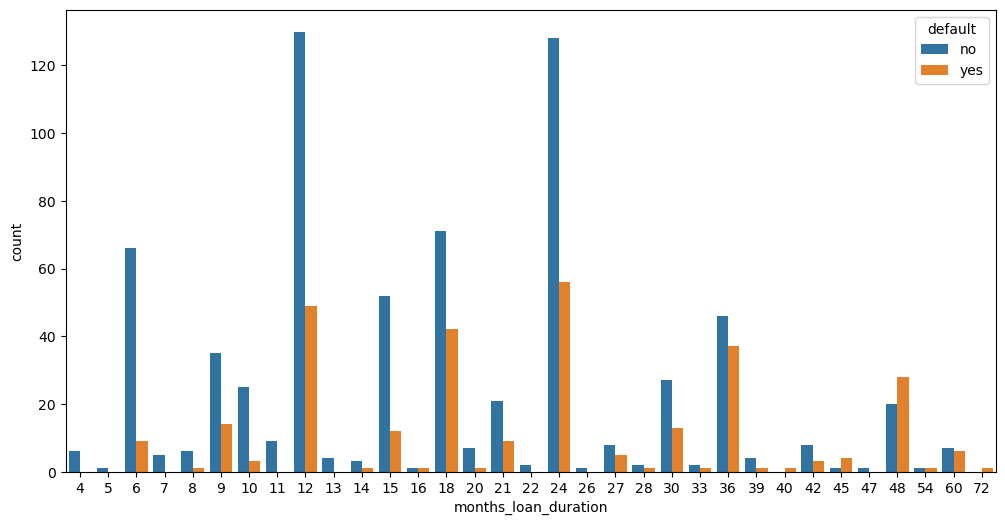

In [4]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="months_loan_duration",hue="default")

<Axes: xlabel='credit_history', ylabel='count'>

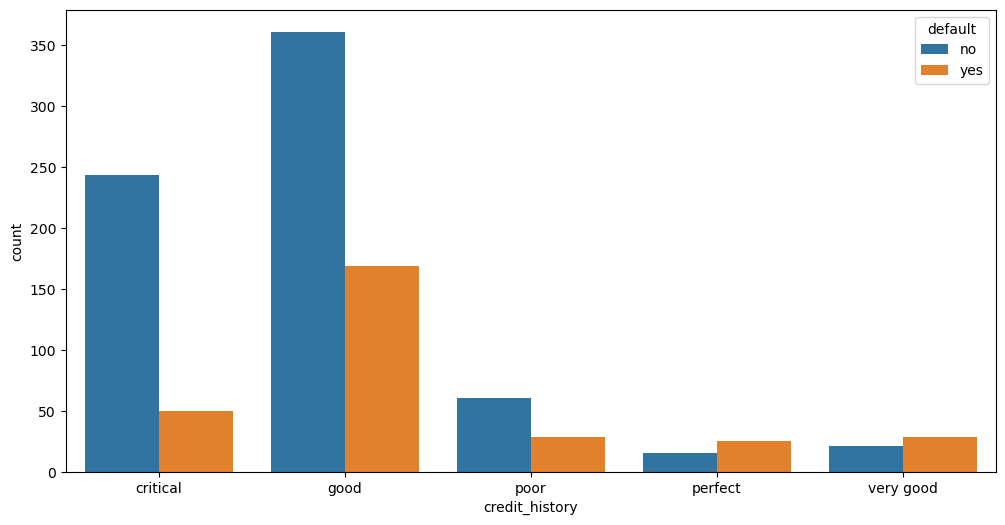

In [5]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="credit_history",hue="default")

<Axes: xlabel='purpose', ylabel='count'>

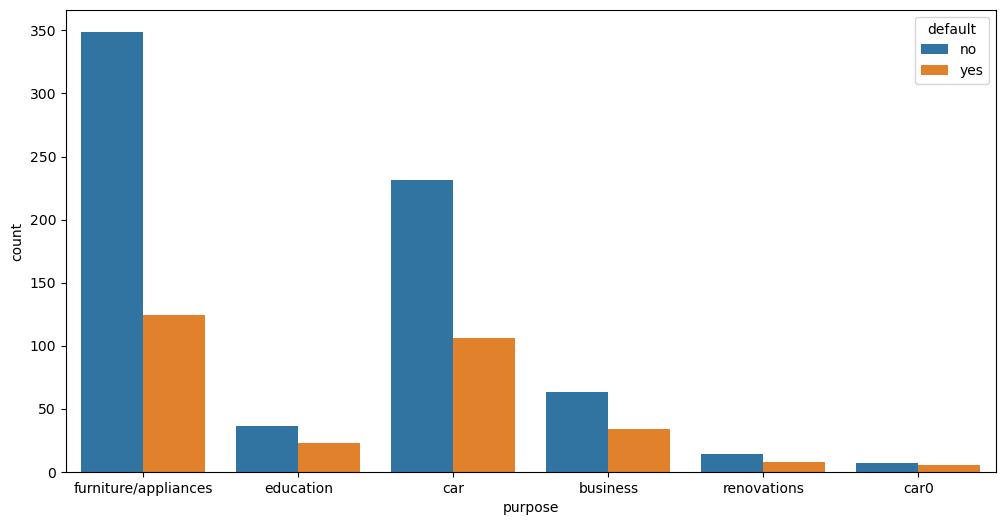

In [6]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="purpose",hue="default")

<Axes: xlabel='savings_balance', ylabel='count'>

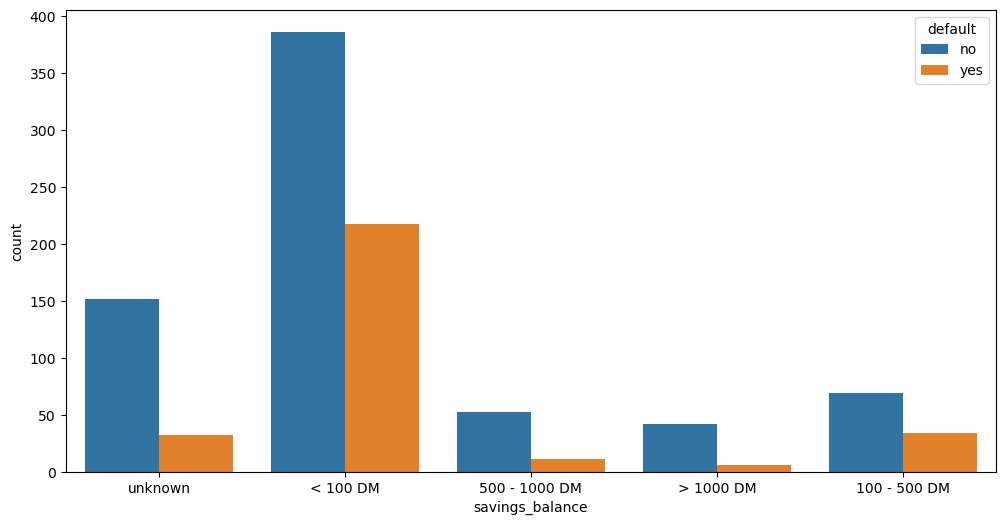

In [7]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="savings_balance",hue="default")

<Axes: xlabel='employment_duration', ylabel='count'>

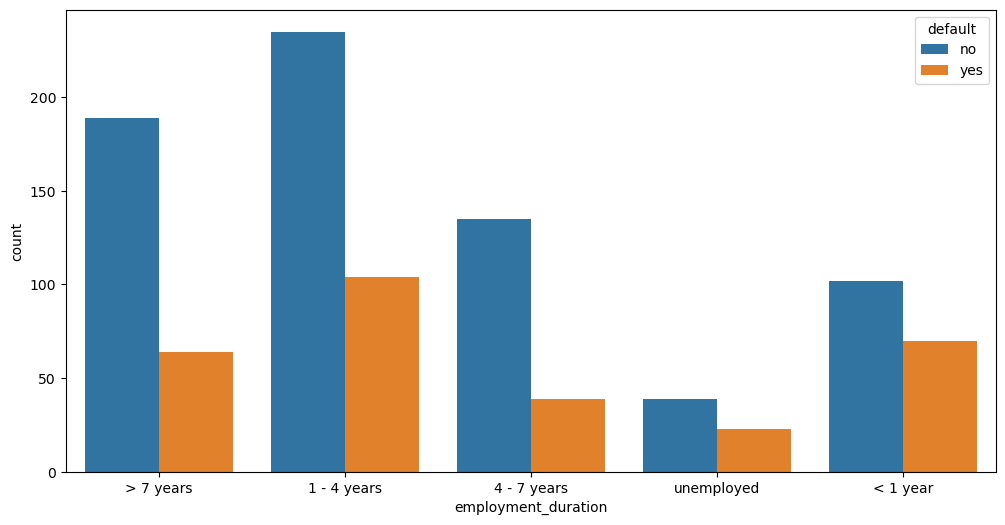

In [8]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="employment_duration",hue="default")

<Axes: xlabel='percent_of_income', ylabel='count'>

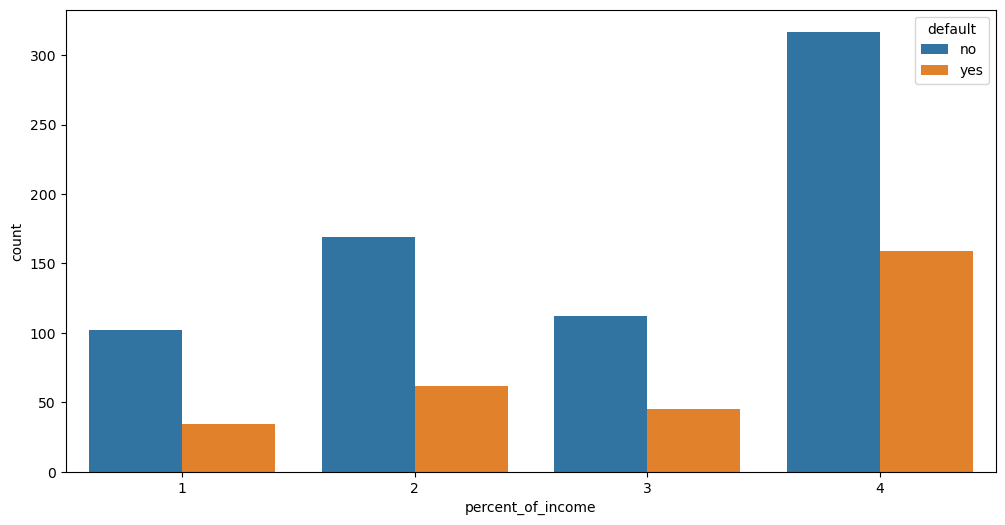

In [9]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="percent_of_income",hue="default")

<Axes: xlabel='years_at_residence', ylabel='count'>

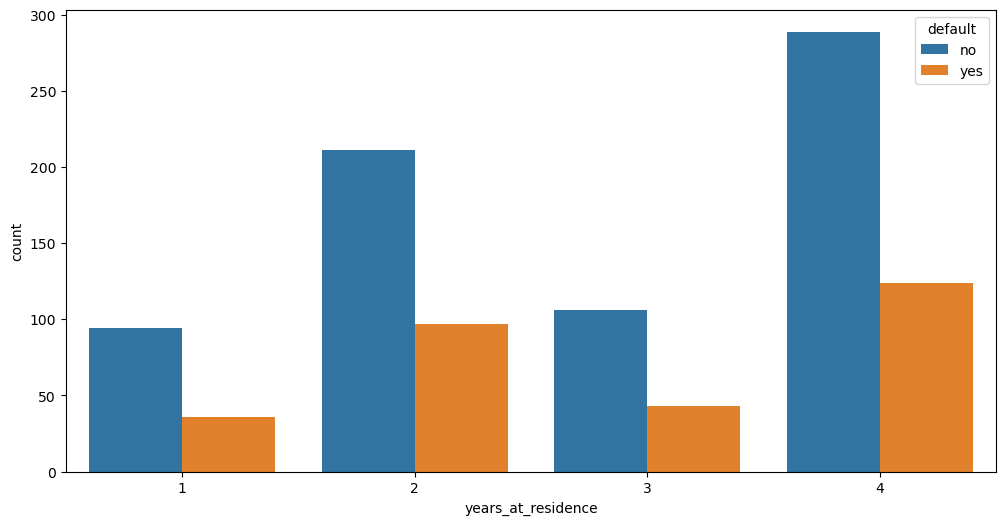

In [10]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="years_at_residence",hue="default")

<Axes: xlabel='age', ylabel='count'>

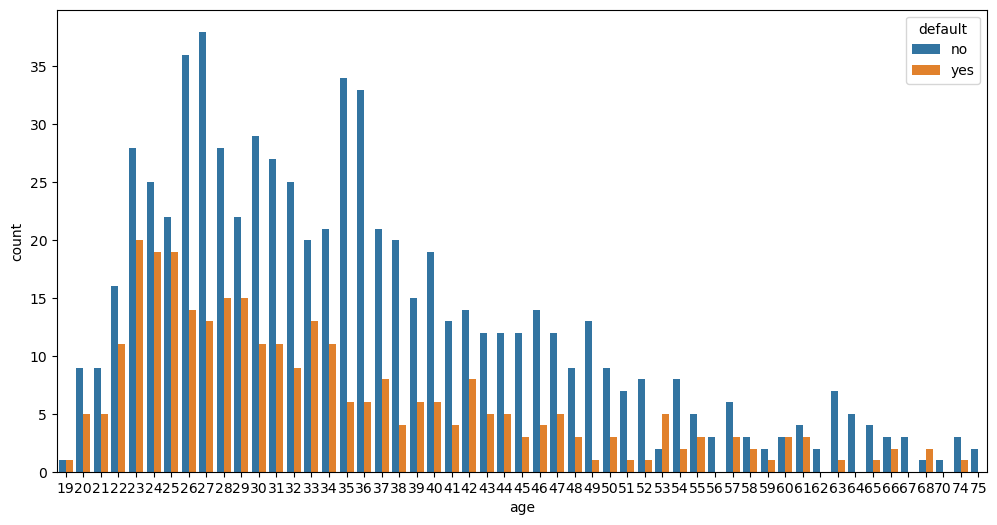

In [11]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="age",hue="default")

<Axes: xlabel='other_credit', ylabel='count'>

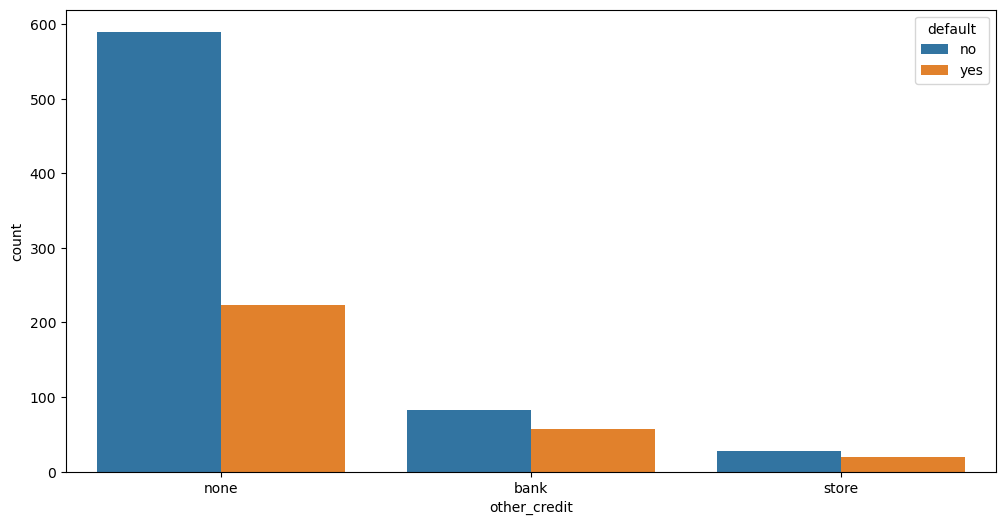

In [12]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="other_credit",hue="default")

<Axes: xlabel='housing', ylabel='count'>

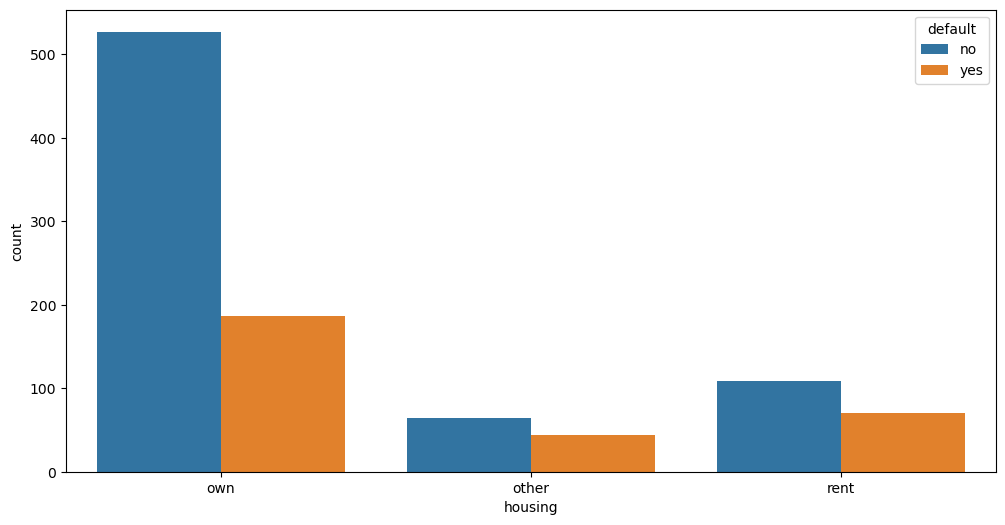

In [13]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="housing",hue="default")

<Axes: xlabel='existing_loans_count', ylabel='count'>

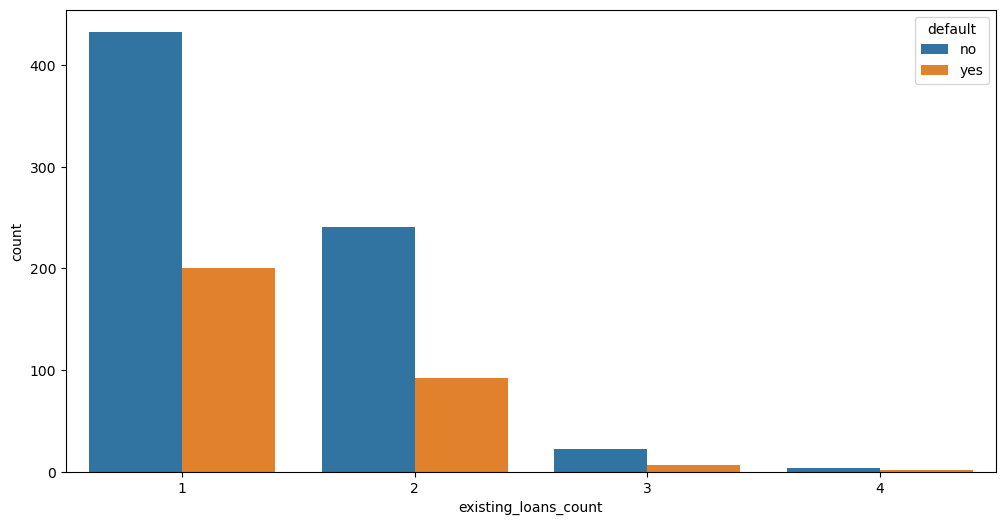

In [14]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="existing_loans_count",hue="default")

<Axes: xlabel='job', ylabel='count'>

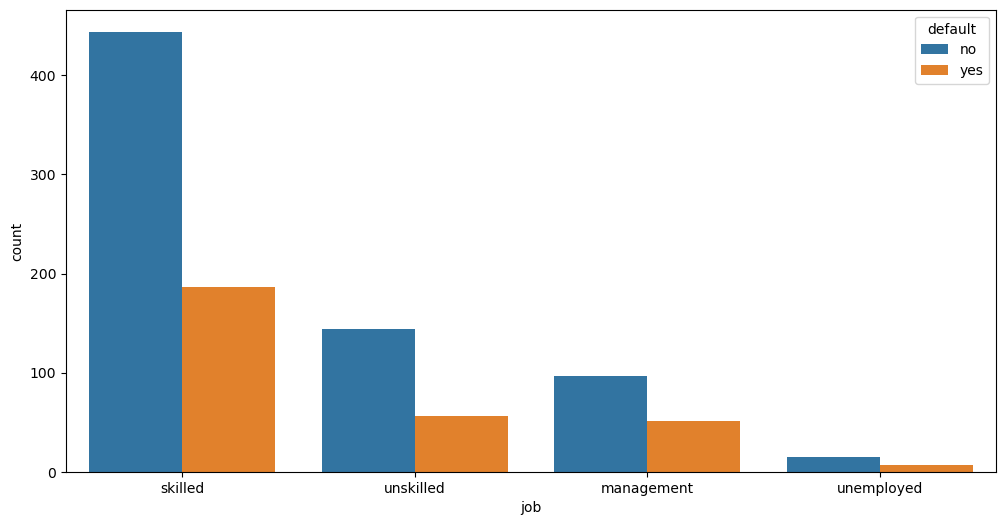

In [15]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="job",hue="default")

<Axes: xlabel='dependents', ylabel='count'>

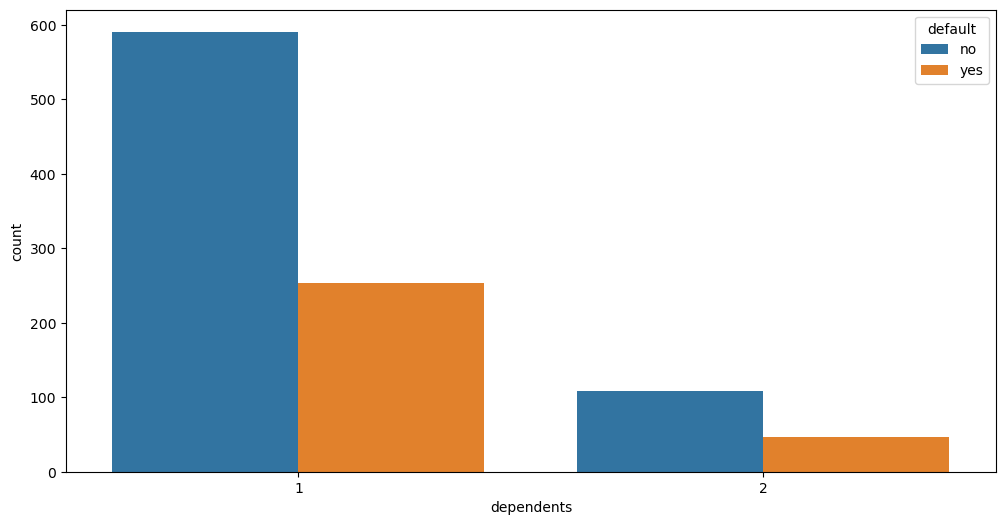

In [16]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="dependents",hue="default")

<Axes: xlabel='phone', ylabel='count'>

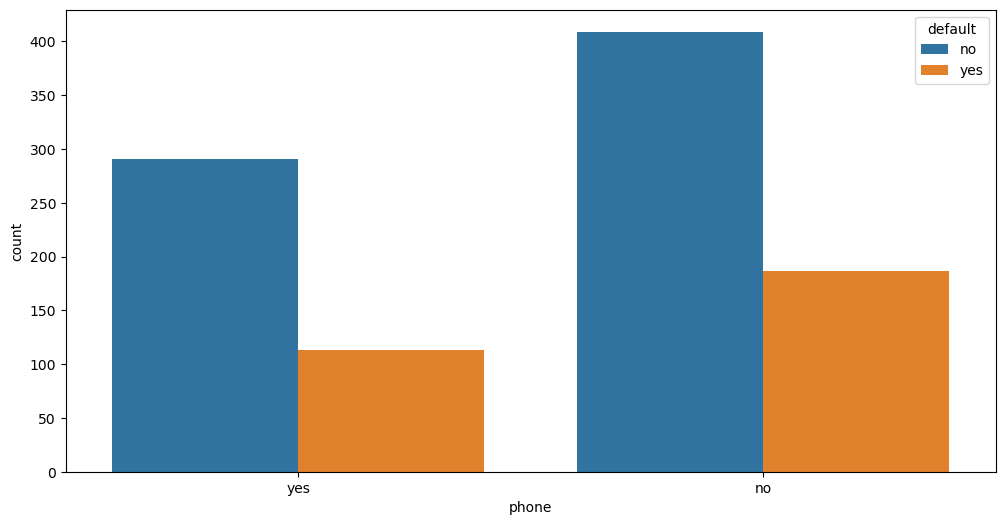

In [17]:
plt.figure(figsize=(12, 6))    # set a plot size (12,6)
sns.countplot(data=df,x="phone",hue="default")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

pre-processing all the non-numeric/object type data into usable numeric type ones

Converting the 'unknown' into nan for easier computations

In [19]:
df['checking_balance'] = df['checking_balance'].map({'unknown':np.nan, '< 0 DM':0,'1 - 200 DM':1,
                                                     '> 200 DM':2,}).astype('float')

In [20]:
df['credit_history'] = df['credit_history'].map({'critical':0, 'poor':1, 'good':2, 'very good':3, 'perfect':4}).astype('float')

I am guessing the car0 in 'purpose' is a typo and I am providing it the same encode as car.

In [21]:
df['purpose'] = df['purpose'].map({'furniture/appliances':0, 'car':1, 'business':2, 'education':3,
                                   'renovations':4, 'car0':1}).astype('float')

In [22]:
df['savings_balance'] = df['savings_balance'].map({'unknown':np.nan, '< 100 DM':0,'100 - 500 DM':1,
                                                   '500 - 1000 DM':2, '> 1000 DM':3}).astype('float')

In [23]:
df['employment_duration'] = df['employment_duration'].map({'unemployed':0,'< 1 year':1, '1 - 4 years':2,
                                                           '4 - 7 years':3, '> 7 years':4}).astype('float')

In [24]:
df['other_credit'] = df['other_credit'].map({'none':0,'bank':1, 'store':2}).astype('float')

In [25]:
df['housing'] = df['housing'].map({'own':0,'rent':1, 'other':2}).astype('float')

In [26]:
df['job'] = df['job'].map({'unemployed':0,'unskilled':1, 'skilled':2, 'management':3}).astype('float')

In [27]:
df['phone'] = df['phone'].map({'yes':1,'no':0}).astype('float')

In [28]:
df['default'] = df['default'].map({'yes':1,'no':0}).astype('float')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   checking_balance      606 non-null    float64
 1   months_loan_duration  1000 non-null   int64  
 2   credit_history        1000 non-null   float64
 3   purpose               1000 non-null   float64
 4   amount                1000 non-null   int64  
 5   savings_balance       817 non-null    float64
 6   employment_duration   1000 non-null   float64
 7   percent_of_income     1000 non-null   int64  
 8   years_at_residence    1000 non-null   int64  
 9   age                   1000 non-null   int64  
 10  other_credit          1000 non-null   float64
 11  housing               1000 non-null   float64
 12  existing_loans_count  1000 non-null   int64  
 13  job                   1000 non-null   float64
 14  dependents            1000 non-null   int64  
 15  phone                 

In [30]:
df

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,0.0,6,0.0,0.0,1169,NaN,4.0,4,4,67,0.0,0.0,2,2.0,1,1.0,0.0
1,1.0,48,2.0,0.0,5951,0.0,2.0,2,2,22,0.0,0.0,1,2.0,1,0.0,1.0
2,NaN,12,0.0,3.0,2096,0.0,3.0,2,3,49,0.0,0.0,1,1.0,2,0.0,0.0
3,0.0,42,2.0,0.0,7882,0.0,3.0,2,4,45,0.0,2.0,1,2.0,2,0.0,0.0
4,0.0,24,1.0,1.0,4870,0.0,2.0,3,4,53,0.0,2.0,2,2.0,2,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,12,2.0,0.0,1736,0.0,3.0,3,4,31,0.0,0.0,1,1.0,1,0.0,0.0
996,0.0,30,2.0,1.0,3857,0.0,2.0,4,4,40,0.0,0.0,1,3.0,1,1.0,0.0
997,NaN,12,2.0,0.0,804,0.0,4.0,4,4,38,0.0,0.0,1,2.0,1,0.0,0.0
998,0.0,45,2.0,0.0,1845,0.0,2.0,4,4,23,0.0,2.0,1,2.0,1,1.0,1.0


With all the Non-numeric/Object data converted to numeric. we can now either fill the empty datacells using imputation methods or drop the missing vauled rows entirely from the dataframe.

In [31]:
df0 = df.dropna()                            # dropping all the missing valued rows

In [32]:
df0

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
1,1.0,48,2.0,0.0,5951,0.0,2.0,2,2,22,0.0,0.0,1,2.0,1,0.0,1.0
3,0.0,42,2.0,0.0,7882,0.0,3.0,2,4,45,0.0,2.0,1,2.0,2,0.0,0.0
4,0.0,24,1.0,1.0,4870,0.0,2.0,3,4,53,0.0,2.0,2,2.0,2,0.0,1.0
7,1.0,36,2.0,1.0,6948,0.0,2.0,2,2,35,0.0,1.0,1,3.0,1,1.0,0.0
9,1.0,30,0.0,1.0,5234,0.0,0.0,4,2,28,0.0,0.0,2,3.0,1,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,1.0,24,0.0,0.0,1743,0.0,4.0,4,2,48,0.0,0.0,2,1.0,1,0.0,0.0
993,0.0,36,2.0,0.0,3959,0.0,0.0,4,3,30,0.0,0.0,1,3.0,1,1.0,0.0
996,0.0,30,2.0,1.0,3857,0.0,2.0,4,4,40,0.0,0.0,1,3.0,1,1.0,0.0
998,0.0,45,2.0,0.0,1845,0.0,2.0,4,4,23,0.0,2.0,1,2.0,1,1.0,1.0


In [33]:
df0.isna().sum()

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64

Imputation is the process of replacing missing values with substituted data. It is done as a preprocessing step. For more information look into the following references. Anyway in this project I am using 2 imputer from sklearn class - simple imputer and knnimputer(model based imputation)

References:
- https://towardsdatascience.com/different-imputation-methods-to-handle-missing-data-8dd5bce97583
- https://www.geeksforgeeks.org/ml-handle-missing-data-with-simple-imputer/
- https://www.geeksforgeeks.org/python-imputation-using-the-knnimputer/

In [34]:
imputer = SimpleImputer(missing_values = np.nan, strategy ='most_frequent')
imputer = imputer.fit(df)
df1 = imputer.transform(df)

In [35]:
df1

array([[ 0.,  6.,  0., ...,  1.,  1.,  0.],
       [ 1., 48.,  2., ...,  1.,  0.,  1.],
       [ 0., 12.,  0., ...,  2.,  0.,  0.],
       ...,
       [ 0., 12.,  2., ...,  1.,  0.,  0.],
       [ 0., 45.,  2., ...,  1.,  1.,  1.],
       [ 1., 45.,  0., ...,  1.,  0.,  0.]])

In [36]:
df1 = pd.DataFrame(df1, columns=df.columns, index=df.index)

In [37]:
df1

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,0.0,6.0,0.0,0.0,1169.0,0.0,4.0,4.0,4.0,67.0,0.0,0.0,2.0,2.0,1.0,1.0,0.0
1,1.0,48.0,2.0,0.0,5951.0,0.0,2.0,2.0,2.0,22.0,0.0,0.0,1.0,2.0,1.0,0.0,1.0
2,0.0,12.0,0.0,3.0,2096.0,0.0,3.0,2.0,3.0,49.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0
3,0.0,42.0,2.0,0.0,7882.0,0.0,3.0,2.0,4.0,45.0,0.0,2.0,1.0,2.0,2.0,0.0,0.0
4,0.0,24.0,1.0,1.0,4870.0,0.0,2.0,3.0,4.0,53.0,0.0,2.0,2.0,2.0,2.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,12.0,2.0,0.0,1736.0,0.0,3.0,3.0,4.0,31.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
996,0.0,30.0,2.0,1.0,3857.0,0.0,2.0,4.0,4.0,40.0,0.0,0.0,1.0,3.0,1.0,1.0,0.0
997,0.0,12.0,2.0,0.0,804.0,0.0,4.0,4.0,4.0,38.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0
998,0.0,45.0,2.0,0.0,1845.0,0.0,2.0,4.0,4.0,23.0,0.0,2.0,1.0,2.0,1.0,1.0,1.0


In [38]:
df1.isna().sum()

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64

In [39]:
imputer = KNNImputer(n_neighbors=2)
df2 = imputer.fit_transform(df)
df2 = np.floor(df2)

In [40]:
print(df2[0])

[0.000e+00 6.000e+00 0.000e+00 0.000e+00 1.169e+03 0.000e+00 4.000e+00
 4.000e+00 4.000e+00 6.700e+01 0.000e+00 0.000e+00 2.000e+00 2.000e+00
 1.000e+00 1.000e+00 0.000e+00]


In [41]:
df2 = pd.DataFrame(df2, columns=df.columns, index=df.index)

In [42]:
df2

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,0.0,6.0,0.0,0.0,1169.0,0.0,4.0,4.0,4.0,67.0,0.0,0.0,2.0,2.0,1.0,1.0,0.0
1,1.0,48.0,2.0,0.0,5951.0,0.0,2.0,2.0,2.0,22.0,0.0,0.0,1.0,2.0,1.0,0.0,1.0
2,2.0,12.0,0.0,3.0,2096.0,0.0,3.0,2.0,3.0,49.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0
3,0.0,42.0,2.0,0.0,7882.0,0.0,3.0,2.0,4.0,45.0,0.0,2.0,1.0,2.0,2.0,0.0,0.0
4,0.0,24.0,1.0,1.0,4870.0,0.0,2.0,3.0,4.0,53.0,0.0,2.0,2.0,2.0,2.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,12.0,2.0,0.0,1736.0,0.0,3.0,3.0,4.0,31.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
996,0.0,30.0,2.0,1.0,3857.0,0.0,2.0,4.0,4.0,40.0,0.0,0.0,1.0,3.0,1.0,1.0,0.0
997,0.0,12.0,2.0,0.0,804.0,0.0,4.0,4.0,4.0,38.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0
998,0.0,45.0,2.0,0.0,1845.0,0.0,2.0,4.0,4.0,23.0,0.0,2.0,1.0,2.0,1.0,1.0,1.0


In [43]:
df2.isna().sum()

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64

We now have three different dataframes - df0,df1 and df2, which we got from the original dataframe df. df0 contains all the datacells with missing valued rows dropped. df1 contains all the missing datacells filled with mode of that feature. df2 contains all the datacells with missing values predicted using knn model.

Due to the fact that the response variable is binary, I am choosing Logistic Regression as my model building algorithm

### model training with df0


In [44]:
X = df0.drop('default', axis=1).astype('float')
y = df0['default']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=1)

In [46]:
lr = LogisticRegression(max_iter=1000, solver='newton-cholesky')
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000, solver='newton-cholesky')

In [47]:
pred = lr.predict(X_test)
print('Accuracy of this model is', accuracy_score(y_test, pred))

Accuracy of this model is 0.6114649681528662


In [48]:
print(lr.coef_)

[[-3.95292127e-01  3.59809707e-02  4.81570583e-01  2.15088802e-01
   8.14345720e-05 -4.84492185e-01 -8.74518296e-02  3.52602446e-01
   1.82329257e-01 -1.29123109e-02  1.61110032e-01  8.27254797e-02
   5.66476642e-01  2.09846361e-01 -1.79681216e-01 -1.47854929e-01]]


LogisticRegression of sklearn does not have the summary function which could be useful to study the statistical significance of the predictor variables.

In [49]:
X_train = sm.add_constant(X_train)

# fit a logistic regression model using statsmodels
model = sm.Logit(y_train, X_train)
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.561249
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                  365
Model:                          Logit   Df Residuals:                      348
Method:                           MLE   Df Model:                           16
Date:                Mon, 06 May 2024   Pseudo R-squ.:                  0.1842
Time:                        22:43:56   Log-Likelihood:                -204.86
converged:                       True   LL-Null:                       -251.12
Covariance Type:            nonrobust   LLR p-value:                 8.538e-13
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -3.8063      0.952     -3.998      0.000      -5.672      -1.940
checking_balance        -0.4083      0.192     -2.129      0.033      -0.784      -0.032
months_loan_duration     0.0360      0.012      2.888      0.004       0.012       0.060
credit_history           0.4983      0.132      3.781      0.000       0.240       0.757
purpose                  0.2221      0.128      1.729      0.084      -0.030       0.474
amount                8.229e-05   6.07e-05      1.355      0.175   -3.68e-05       0.000
savings_balance         -0.5009      0.177     -2.837      0.005      -0.847      -0.155
employment_duration     -0.0893      0.107     -0.831      0.406      -0.300       0.121
percent_of_income        0.3587      0.125      2.871      0.004       0.114       0.604
years_at_residence       0.1859      0.123      1.506      0.132      -0.056       0.428
age                     -0.0129      0.012     -1.088      0.277      -0.036       0.010
other_credit             0.1632      0.222      0.736      0.462      -0.272       0.598
housing                  0.0808      0.195      0.415      0.678      -0.301       0.462
existing_loans_count     0.6085      0.244      2.494      0.013       0.130       1.087
job                      0.2242      0.204      1.100      0.271      -0.175       0.623
dependents              -0.2082      0.357     -0.582      0.560      -0.909       0.492
phone                   -0.1694      0.278     -0.610      0.542      -0.714       0.375
========================================================================================
"""

From the Above Summary table you can see that only 6 out of the 16 predictor variables are statistically significant which are checking_balance, months_loan_duration, credit_history, savings_balance, percent_of_income, existing_loans_count meaning only these predictor variables show a relationship while more data is needed to see if the rest of the 10 predictor variables have any relation with customers defaulting

sklearn's LogisticRegression and statsmodel's Logit and are used to implement Logistic Regression algorithm,if you look at the coefficient values of the predictor variables you can find some differences between them which is due to the const in Logit's implementation so these differences can be ignored. 

The Accuracy with reduced sample sized data due to dropping the missing valued rows is 61%. which is not bad but could be improved.

In [50]:
X = df0[['checking_balance', 'months_loan_duration', 'credit_history', 'savings_balance', 'percent_of_income', 'existing_loans_count']]
y = df0['default']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=1)

In [52]:
lr = LogisticRegression(max_iter=1000, solver='newton-cholesky')
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000, solver='newton-cholesky')

In [53]:
pred = lr.predict(X_test)
print('Accuracy of this model is', accuracy_score(y_test, pred))

Accuracy of this model is 0.6114649681528662


as you can see the accuracy of the model is still the same with reduced predictor features

### Model training with df1

In [54]:
X = df1.drop('default', axis=1).astype('float')
y = df1['default']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=1)

In [56]:
lr = LogisticRegression(max_iter=1000, solver='newton-cholesky')
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000, solver='newton-cholesky')

In [57]:
pred = lr.predict(X_test)
print('Accuracy of this model is', accuracy_score(y_test, pred))

Accuracy of this model is 0.6933333333333334


In [58]:
X_train = sm.add_constant(X_train)

# fit a logistic regression model using statsmodels
model = sm.Logit(y_train, X_train)
result = model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.515537
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                  700
Model:                          Logit   Df Residuals:                      683
Method:                           MLE   Df Model:                           16
Date:                Mon, 06 May 2024   Pseudo R-squ.:                  0.1626
Time:                        22:43:57   Log-Likelihood:                -360.88
converged:                       True   LL-Null:                       -430.94
Covariance Type:            nonrobust   LLR p-value:                 6.801e-22
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -3.6615      0.715     -5.118      0.000      -5.064      -2.259
checking_balance         0.1415      0.152      0.929      0.353      -0.157       0.440
months_loan_duration     0.0236      0.010      2.330      0.020       0.004       0.044
credit_history           0.6408      0.105      6.080      0.000       0.434       0.847
purpose                  0.1604      0.100      1.598      0.110      -0.036       0.357
amount                9.967e-05   4.78e-05      2.084      0.037    5.94e-06       0.000
savings_balance         -0.3527      0.134     -2.634      0.008      -0.615      -0.090
employment_duration     -0.2182      0.082     -2.671      0.008      -0.378      -0.058
percent_of_income        0.3681      0.096      3.848      0.000       0.181       0.556
years_at_residence       0.1137      0.092      1.237      0.216      -0.067       0.294
age                     -0.0213      0.009     -2.365      0.018      -0.039      -0.004
other_credit             0.2035      0.164      1.239      0.215      -0.118       0.526
housing                  0.2206      0.140      1.572      0.116      -0.054       0.495
existing_loans_count     0.3916      0.191      2.048      0.041       0.017       0.766
job                      0.0313      0.162      0.193      0.847      -0.286       0.349
dependents               0.1475      0.272      0.543      0.587      -0.385       0.680
phone                   -0.5754      0.220     -2.615      0.009      -1.007      -0.144
========================================================================================
"""

### Model training with df2

In [59]:
X = df2.drop('default', axis=1).astype('float')
y = df2['default']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=1)

In [61]:
lr = LogisticRegression(max_iter=1000, solver='newton-cholesky')
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000, solver='newton-cholesky')

In [62]:
pred = lr.predict(X_test)
print('Accuracy of this model is', accuracy_score(y_test, pred))

Accuracy of this model is 0.7


In [63]:
X_train = sm.add_constant(X_train)

# fit a logistic regression model using statsmodels
model = sm.Logit(y_train, X_train)
result = model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.513515
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                  700
Model:                          Logit   Df Residuals:                      683
Method:                           MLE   Df Model:                           16
Date:                Mon, 06 May 2024   Pseudo R-squ.:                  0.1659
Time:                        22:43:58   Log-Likelihood:                -359.46
converged:                       True   LL-Null:                       -430.94
Covariance Type:            nonrobust   LLR p-value:                 1.896e-22
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -3.4585      0.718     -4.817      0.000      -4.866      -2.051
checking_balance        -0.2102      0.155     -1.360      0.174      -0.513       0.093
months_loan_duration     0.0239      0.010      2.364      0.018       0.004       0.044
credit_history           0.6465      0.106      6.107      0.000       0.439       0.854
purpose                  0.1586      0.101      1.574      0.116      -0.039       0.356
amount                   0.0001   4.77e-05      2.097      0.036    6.54e-06       0.000
savings_balance         -0.3726      0.131     -2.843      0.004      -0.629      -0.116
employment_duration     -0.2034      0.082     -2.477      0.013      -0.364      -0.042
percent_of_income        0.3670      0.096      3.830      0.000       0.179       0.555
years_at_residence       0.0982      0.092      1.065      0.287      -0.083       0.279
age                     -0.0204      0.009     -2.253      0.024      -0.038      -0.003
other_credit             0.1910      0.165      1.155      0.248      -0.133       0.515
housing                  0.2179      0.140      1.553      0.120      -0.057       0.493
existing_loans_count     0.3906      0.192      2.031      0.042       0.014       0.767
job                      0.0318      0.162      0.196      0.844      -0.285       0.349
dependents               0.1122      0.273      0.411      0.681      -0.423       0.647
phone                   -0.5823      0.220     -2.641      0.008      -1.014      -0.150
========================================================================================
"""

The accuracy of the model trained with missing values filled using SimpleImputer is 69.3%, while the model trained with missing values filled using KNNImputer has an accuracy of 70%. As you can see, there is only a small improvement in accuracy. This suggests that filling missing values with the mode of that feature is correct most of the time. However, there are a few instances where SimpleImputer gets the missing values wrong, and these cases are correctly predicted by KNNImputer, leading to a slight increase in accuracy.

From the summary table you can draw findings such as "older people are less likely to default a loan" due to the negative relation between age(statistically significant) and default

In conclusion this third model train using missing data filled with KNNimputer is the best model with an accuracy of 70%.